In [1]:
import os
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

In [2]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import data_processing, compute_anomalies_and_scalers, \
                            compute_forced_response, \
                            numpy_to_torch, merge_models_and_runs, rescale_training_set, stack_models_and_runs

# from leave_one_out import leave_one_out_procedure

from algorithms import ridge_regression, ridge_regression_low_rank, proximal_algorithm_ridge_trace_penalty,\
                        compute_gradient,train_robust_weights_trace_norm,\
                        prediction, compute_weights, prediction_training_set

In [3]:
############### Load climate model raw data for SST
with open('data/ssp585_time_series.pkl', 'rb') as f:
    data = pickle.load(f)

###################### Load longitude and latitude 
with open('data/lon.npy', 'rb') as f:
    lon = np.load(f)

with open('data/lat.npy', 'rb') as f:
    lat = np.load(f)

# define grid (+ croping for latitude > 60)
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')

lat_size = lat_grid.shape[0]
lon_size = lon_grid.shape[1]

In [4]:
# define pytorch precision
dtype = torch.float32

time_length = 34

data_processed, notnan_idx, nan_idx = data_processing(data, lon, lat,max_models=100)
x, means, vars = compute_anomalies_and_scalers(data_processed, lon_size, lat_size, nan_idx, time_period=time_length)
y = compute_forced_response(x)
x,y, means, vars = numpy_to_torch(x,y,means,vars, dtype=dtype)

/home/vcohen/cope/src/preprocessing.py:96: RuntimeWarning: Degrees of freedom <= 0 for slice.
  vars[m] = np.nanvar(data_reshaped[m],axis=(0))
/home/vcohen/cope/src/preprocessing.py:101: RuntimeWarning: Mean of empty slice
  data_reshaped[m] = data_reshaped[m] - np.expand_dims(np.nanmean(data_reshaped[m],axis=1),axis=1).repeat(data_reshaped[m].shape[1],axis=1)
/home/vcohen/cope/src/preprocessing.py:151: RuntimeWarning: Mean of empty slice
  data_forced_response[m] = np.expand_dims(np.nanmean(data[m],axis=0),axis=0).repeat(data[m].shape[0],axis=0)


In [5]:
# from preprocessing import compute_smooth_variance

def compute_smooth_variance(data, smoothing=0.25):
    """ Compute smoothed variance.

        Args:
            - data: dictionary, preprocessed data
            - time_period: Int, time series lentgh (target period 1981-2015)
            
        Return:
            - data_anomalies: dictionary of centered (according to a specific definition) data
    """
    # compute the forced response
    vars = {}

    for idx_m,m in enumerate(data.keys()):
        
        var_tmp= np.nanvar(data[m],axis=0)
        sigma0 = np.repeat(np.expand_dims(np.nanmedian(var_tmp,axis=1),axis=1),data[m].shape[2],axis=1)

        # compute the smoothed variance
        vars[m] = torch.from_numpy(smoothing*sigma0 + (1-smoothing)*var_tmp)

    return vars

vars_tmp = compute_smooth_variance(x, smoothing=0.1)

/tmp/ipykernel_45548/3971467822.py:18: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_tmp= np.nanvar(data[m],axis=0)


In [6]:
m0 = 'GISS-E2-2-G'  # use the first model as a reference

training_models, x_rescaled, y_rescaled = rescale_training_set(m0,x,y,means,vars_tmp,dtype=dtype)
training_models, x_train, y_train, x_test, y_test  = merge_models_and_runs(m0,x_rescaled,y_rescaled,means,vars_tmp,dtype=dtype)
x_stacked, y_stacked = stack_models_and_runs(training_models, x_rescaled, y_rescaled)


x_tmp = x_stacked.view(-1, x_stacked.shape[2])
y_tmp = y_stacked.view(-1, y_stacked.shape[2])

In [7]:
# import tensorly as tl
# from tensorly.decomposition import parafac

# data_tmp = np.random.random((30, 40, 50))

# # Perform CP decomposition with rank=3
# factors = parafac(data_tmp, rank=3)

# # The result is a list of factor matrices (one for each mode)
# A, B, C = factors.factors  # or factors[0], factors[1], factors[2]

# print("Shape of factor matrices:")
# print("A:", A.shape)
# print("B:", B.shape)
# print("C:", C.shape)

In [8]:
# U = np.random.random((1000, 1000,34))
# factors = parafac(U, rank=3)

# # The result is a list of factor matrices (one for each mode)
# A, B, C = factors.factors  # or factors[0], factors[1], factors[2]

# 

# Trace norm regression

In [9]:
from algorithms import singular_value_thresholding

def proximal_algorithm_ridge_trace_penalty(X,Y,lambda_,nu_,lr=0.1,nb_iterations=10,dtype=torch.float32,verbose=False):
    """This function runs the proximal gradient algorithm to solve the optimization problem min f(W) + g(W) 
      where f(W) = 1/2 ||Y - XW||_F^2 and g(W) = lambda * ||W||_F^2 + nu * ||W||_*

    Args:
        - X, Y: input-output pair
        - lambda_: ridge penalty coefficient
        - nu_: trace norm penalty coefficient
        - lr: learning rate
        - nb_iterations: number of iterations

    Returns:
        - w: optimal regressor matrix
        - training_loss: training loss
    """
    w = torch.zeros(X.shape[1],Y.shape[1], dtype=dtype)
    loss = torch.zeros(nb_iterations, dtype=dtype)

    for it in range(nb_iterations):

        # compute gradient
        
        grad = X.T @ (X @ w - Y) + lambda_ * w

        # update the variable w
        w = w - lr * grad

        # compute proximal operator of trace norm and frobenius norm
        w = singular_value_thresholding(w, lr*nu_)

        # lr = lr/2

        if verbose==True:
            # compute training loss
            obj = 0.5 * torch.norm(Y - X @ w,p='fro')**2 + lambda_ * torch.norm(w,p='fro')**2 + nu_ * torch.norm(w,p='nuc')
            loss[it] = obj.item()
            print("Iteration ", it,  ": Loss function : ", obj.item())

    return w, loss

In [ ]:
#################################################### train models #########################################

# train ridge regression
# compute the proximal operator of the elastic net penalty
lambda_tmp = 100.0
rank_tmp = 5

# ridge regression
w_ridge = torch.zeros(x_train.shape[1],y_train.shape[1],dtype=dtype)
w_ridge[np.ix_(notnan_idx,notnan_idx)] = ridge_regression(x_train[:,notnan_idx], y_train[:,notnan_idx], lambda_= len(training_models)*lambda_tmp, verbose=False, dtype=dtype)

print("rank of matrix w ", torch.linalg.matrix_rank(w_ridge[np.ix_(notnan_idx,notnan_idx)]))
# ridge regression with low rank constraints
w_ridge_lr = torch.zeros(x_train.shape[1],y_train.shape[1],dtype=dtype)
w_ridge_lr[np.ix_(notnan_idx,notnan_idx)] = ridge_regression_low_rank(x_train[:,notnan_idx], y_train[:,notnan_idx], rank=rank_tmp, lambda_=len(training_models)*lambda_tmp,dtype=dtype,verbose=False)

print("rank of matrix w ", torch.linalg.matrix_rank(w_ridge_lr[np.ix_(notnan_idx,notnan_idx)]))

rank of matrix w  tensor(460)
rank of matrix w  tensor(5)


In [ ]:
m_test = 'GISS-E2-2-G'  # use the first model as a test set

x_test_tmp = x[m_test]
y_test_tmp = y[m_test]

# ridge
y_pred_ridge = prediction(x_test_tmp, w_ridge,notnan_idx, nan_idx)
print("Shape of y_pred_ridge: ", y_pred_ridge.shape)

# low rank prediction
y_pred_ridge_lr = prediction(x_test_tmp, w_ridge_lr,notnan_idx, nan_idx)

# trace norm prediction
# y_pred_trace = prediction(x_test_tmp, w_trace,notnan_idx, nan_idx)

# quantile regression prediction
# y_pred_qr = prediction(x_test_tmp, w_qr_tensor, notnan_idx, nan_idx)


# y_pred_trace_prox = prediction(x_test_tmp, w_trace_prox,notnan_idx, nan_idx)

# compute the mse
mse_ridge = torch.mean(torch.norm(y_test_tmp[:,:,notnan_idx] - y_pred_ridge[:,:,notnan_idx], dim=(1,2))**2) / torch.norm(y_test_tmp[:,:,notnan_idx])**2
mse_ridge_lr = torch.mean(torch.norm(y_test_tmp[:,:,notnan_idx] - y_pred_ridge_lr[:,:,notnan_idx], dim=(1,2))**2) / torch.norm(y_test_tmp[:,:,notnan_idx])**2
# mse_trace = torch.mean(torch.norm(y_test_tmp[:,:,notnan_idx] - y_pred_trace[:,:,notnan_idx], dim=(1,2))**2) / torch.norm(y_test_tmp[:,:,notnan_idx])**2
# mse_qr = torch.mean(torch.norm(y_test_tmp[:,:,notnan_idx] - y_pred_qr[:,:,notnan_idx], dim=(1,2))**2) / torch.norm(y_test_tmp[:,:,notnan_idx])**2

# mse_trace_prox = torch.mean(torch.norm(y_test_tmp[:,:,notnan_idx] - y_pred_trace_prox[:,:,notnan_idx], dim=(1,2))**2) / torch.norm(y_test_tmp[:,:,notnan_idx])**2

print("MSE Ridge: ", mse_ridge.item())
print("MSE Ridge low rank: ", mse_ridge_lr.item())
# print("MSE Trace norm: ", mse_trace.item())
# print("MSE Quantile regression: ", mse_qr.item())
# print("MSE Trace norm proximal: ", mse_trace_prox.item())

Shape of y_pred_ridge:  torch.Size([11, 34, 2592])
MSE Ridge:  0.09140144288539886
MSE Ridge low rank:  0.06127094104886055


In [12]:
# weights_robust = compute_weights(training_models,w_robust,x_rescaled,y_rescaled,notnan_idx,mu_=mu_tmp)
# # weights_trace_norm = compute_weights(training_models,w_robust_trace_norm,x,y,notnan_idx,mu_=mu_tmp)
# # # # # weights_robust_lr = compute_weights(training_models,w_robust_lr,x_rescaled,y_rescaled,notnan_idx,mu_=mu_tmp)

# # # plot the weights
# plt.close('all')
# ################# plot the rmse #################
# fig, ax = plt.subplots()

# # plot robust weights
# ax.bar(training_models, list(weights_robust.values()),label=r'robust weight model')
# ax.set_ylabel('weights')
# ax.set_ylim(0.0,0.25)
# ax.legend()
# ax.set_xticklabels(training_models, rotation=-90)

# plt.tight_layout()
# plt.savefig("results/robust_weights_"+str(mu_tmp)+"_"+str(lambda_tmp)+".eps", dpi=150)
# plt.show()

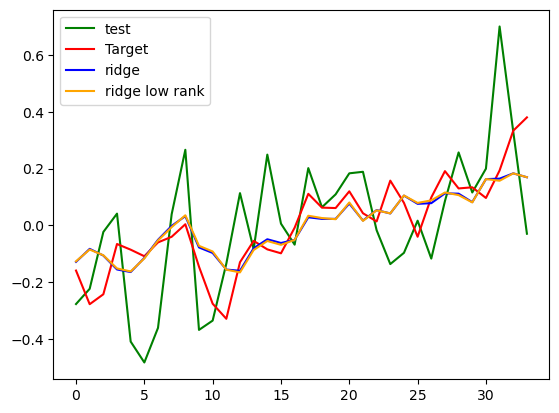

In [13]:
# # plot the weights
plt.close('all')
################# plot the rmse #################
fig, ax = plt.subplots()

# plot the ground truth in a specific location
idx_run = 0
idx_grid_cell = 1000

time_period = time_length


# plot the ground truth
plt.plot(range(time_period),x_test_tmp[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='test',color='green')
# plt.plot(range(time_period),x_test_tmp[idx_run+1,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='GT',color='pink')
plt.plot(range(time_period),y_test_tmp[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='Target',color='red')
plt.plot(range(time_period),y_pred_ridge[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='ridge',color='blue')
plt.plot(range(time_period),y_pred_ridge_lr[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='ridge low rank',color='orange')
# plt.plot(range(time_period),y_pred_robust[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='robust',color='purple')
# plt.plot(range(time_period),x[m0][idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='input',color='green')
# plt.plot(range(time_period),y_pred_ridge_lr[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='input',color='purple')
plt.legend()
plt.show()

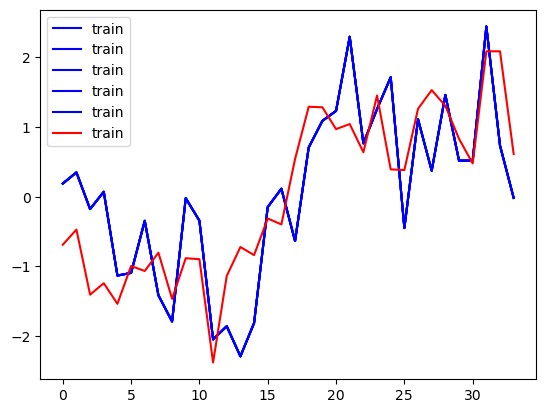

In [14]:
# plot the weights
plt.close('all')
################# plot the rmse #################
fig, ax = plt.subplots()

# plot the ground truth in a specific location
idx_run = 0
idx_grid_cell = 1000

time_period = time_length


# plot the ground truth
for i in range(x_rescaled['ICON-ESM-LR'].shape[0]):
    plt.plot(range(time_period),x_rescaled['ICON-ESM-LR'][idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='train',color='blue')

plt.plot(range(time_period),y_rescaled['ICON-ESM-LR'][idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='train',color='red')
plt.legend()
plt.show()

In [15]:
y_rescaled

{'ICON-ESM-LR': tensor([[[    nan,     nan,     nan,  ..., -0.6663, -0.7015, -0.7213],
          [    nan,     nan,     nan,  ..., -0.6611, -0.6691, -0.6787],
          [    nan,     nan,     nan,  ..., -0.8709, -0.9092, -0.9400],
          ...,
          [    nan,     nan,     nan,  ...,  0.6190,  0.6195,  0.6391],
          [    nan,     nan,     nan,  ...,  1.1544,  1.1735,  1.1562],
          [    nan,     nan,     nan,  ..., -0.1103, -0.1599, -0.1882]],
 
         [[    nan,     nan,     nan,  ..., -0.6663, -0.7015, -0.7213],
          [    nan,     nan,     nan,  ..., -0.6611, -0.6691, -0.6787],
          [    nan,     nan,     nan,  ..., -0.8709, -0.9092, -0.9400],
          ...,
          [    nan,     nan,     nan,  ...,  0.6190,  0.6195,  0.6391],
          [    nan,     nan,     nan,  ...,  1.1544,  1.1735,  1.1562],
          [    nan,     nan,     nan,  ..., -0.1103, -0.1599, -0.1882]],
 
         [[    nan,     nan,     nan,  ..., -0.6663, -0.7015, -0.7213],
          [  

In [16]:
# reshape the data such that X is (Time, Runs, lat*lon)
def stack_runs_for_each_model(models,x,y, dtype=dtype):
    """Stack all ensemble members of all models in a single tensor.

       Args:

       Return:
    """

    for idx_m,m in enumerate(models):
        if idx_m == 0:
            x_stacked = x[m]
            y_stacked = y[m]
        else:   

            x_stacked = torch.cat((x_stacked, x[m]), dim=0)
            y_stacked = torch.cat((y_stacked, y[m]), dim=0)

    return x_stacked, y_stacked

In [17]:
x_stack, y_stack = stack_runs_for_each_model(training_models,x,y)
x_stack = torch.transpose(x_stack,0,1)
y_stack = torch.transpose(y_stack,0,1)


x_stack_test, y_stack_test = stack_runs_for_each_model([m0],x,y)
x_stack_test = torch.transpose(x_stack_test,0,1)
y_stack_test = torch.transpose(y_stack_test,0,1)

In [18]:
# compute laplacian matrix 
def compute_laplacian_matrix(x,lon_size,lat_size):
    """Compute the laplacian matrix of the input data.

       Args:
           x: input data
           lon_size: size of the longitude grid
           lat_size: size of the latitude grid

       Return:
           laplacian matrix
    """
    laplacian = torch.zeros((lon_size*lat_size,lon_size*lat_size),dtype=dtype)
    for i in range(lon_size*lat_size):
        for j in range(lon_size*lat_size):
            if i == j:
                laplacian[i,j] = -4.0
            elif abs(i-j) == 1 or abs(i-j) == lon_size:
                laplacian[i,j] = 1.0
    return laplacian

# compute laplacian matrix in one dimension
def compute_laplacian_matrix_1d(chain_size):
    """Compute the laplacian matrix of the input data.

       Args:
           x: input data
           chain_size: size of the chain graph

       Return:
           laplacian matrix
    """
    laplacian = torch.zeros((chain_size,chain_size),dtype=dtype)
    for i in range(chain_size):
        for j in range(chain_size):
            if i == j:
                laplacian[i,j] = -2.0
            elif abs(i-j) == 1:
                laplacian[i,j] = 1.0
    return laplacian

In [19]:
def ridge_regression_with_temporal_smoothing(X, Y, lambda_=1.0, mu_=1.0,dtype=torch.float32,verbose=False):
    """
    Computes the closed-form solution for reduced rank regression.
    
    Args:
        X (torch.Tensor): Predictor matrix of shape (t, n, p).
        Y (torch.Tensor): Response matrix of shape (t, n, q).
        lambda_ (scalar): Ridge penalty coefficient.
        
    Returns:
        U (torch.Tensor): Low-rank predictor coefficients of shape (p, rank).
        V (torch.Tensor): Low-rank response coefficients of shape (q, rank).
    """
    W_ols = torch.zeros(X.shape[0], X.shape[2],X.shape[2],dtype=dtype)

    # loop over time
    for t in range(X.shape[0]):

        # compute Penroe Morose pseudo inverse of X^T @ X
        P = torch.linalg.inv(X[t,:,:].T @ X[t,:,:] + lambda_ * torch.eye(X.shape[2],dtype=dtype))
    
        # compute ordinary least square solution 
        W_ols[t,:,:] = P @ X[t,:,:].T @ Y[t,:,:]


    # smoothing
    L = compute_laplacian_matrix_1d(time_period)


    # W_ols = torch.mm(torch.linalg.inv(torch.eye(X.shape[0],dtype=dtype) + mu_ * L), W_ols)
    W_ols = torch.einsum('ij,jlp->ilp', torch.linalg.inv(torch.eye(X.shape[0],dtype=dtype) + mu_ * L), W_ols)


    # print loss function 
    # if verbose:
    #     loss = torch.norm(Y - X @ W_ols,p='fro')**2 + lambda_ * torch.norm(W_ols,p='fro')**2
    #     print("Loss function: ", loss.item())
    
    return W_ols


In [20]:
# W_ols = torch.zeros(x_stack.shape[0], x_stack.shape[2],x_stack.shape[2],dtype=dtype)
W_ols = ridge_regression_with_temporal_smoothing(x_stack[:,:,notnan_idx], y_stack[:,:,notnan_idx], lambda_=500.0,mu_=100.0,dtype=torch.float32,verbose=False)
print("W_ols shape: ", W_ols.shape)
y_pred_smoothing = torch.zeros(x_stack_test.shape[0], x_stack_test.shape[1],x_stack_test.shape[2],dtype=dtype)
for i in range(x_stack_test.shape[0]):
    y_pred_smoothing[i,:,notnan_idx] = x_stack_test[i,:,notnan_idx] @ W_ols[i,:,:]

# ridge regression
w_ridge = torch.zeros(x_train.shape[1],y_train.shape[1],dtype=dtype)
w_ridge[np.ix_(notnan_idx,notnan_idx)] = ridge_regression(x_train[:,notnan_idx], y_train[:,notnan_idx], lambda_= 10000.0, verbose=False, dtype=dtype)
y_pred_ridge = x_test_tmp[:,:,notnan_idx] @ w_ridge[np.ix_(notnan_idx,notnan_idx)]

error_tmp = torch.nanmean((y_stack_test - y_pred_smoothing)**2)
error_tmp_ridge = torch.mean((y_test_tmp[:,:,notnan_idx] - y_pred_ridge)**2)

print("MSE Ridge: ", error_tmp_ridge.item())
print("MSE Ridge with temporal smoothing: ", error_tmp.item())

W_ols shape:  torch.Size([34, 1531, 1531])
MSE Ridge:  0.01811567135155201
MSE Ridge with temporal smoothing:  0.08477362245321274


In [21]:
for i in range(x_stack_test.shape[0]):
    print(W_ols[i,:,:])

tensor([[4.8113e-04, 4.3819e-04, 3.4350e-04,  ..., 4.2769e-05, 4.4159e-05,
         4.5868e-05],
        [4.3746e-04, 6.1814e-04, 5.8582e-04,  ..., 3.5337e-05, 3.6584e-05,
         3.7834e-05],
        [3.5048e-04, 5.9895e-04, 7.4880e-04,  ..., 2.8710e-05, 2.9729e-05,
         3.0725e-05],
        ...,
        [2.8827e-05, 2.7440e-05, 3.7472e-05,  ..., 3.0179e-04, 3.0062e-04,
         3.0007e-04],
        [2.9848e-05, 2.8939e-05, 3.9235e-05,  ..., 2.9845e-04, 2.9800e-04,
         2.9800e-04],
        [3.1127e-05, 3.0477e-05, 4.1024e-05,  ..., 2.9574e-04, 2.9584e-04,
         2.9649e-04]])
tensor([[9.7391e-04, 8.8611e-04, 6.9476e-04,  ..., 8.7267e-05, 9.0034e-05,
         9.3488e-05],
        [8.8349e-04, 1.2438e-03, 1.1779e-03,  ..., 7.2952e-05, 7.5430e-05,
         7.7950e-05],
        [7.0787e-04, 1.2049e-03, 1.5063e-03,  ..., 6.0107e-05, 6.2125e-05,
         6.4144e-05],
        ...,
        [5.9138e-05, 5.6989e-05, 7.7540e-05,  ..., 6.0790e-04, 6.0557e-04,
         6.0458e-04],
   

In [22]:
lambda_tmp = 10.0
mu_tmp = 300.0
nu_tmp = 100.0
r = 10

# compute the rmse for the ridge regression
w_ridge, rmse_mean_ridge, weights_ridge, training_loss_ridge = leave_one_out_procedure(x,y,means,vars,\
                                        lon_size,lat_size, notnan_idx, nan_idx,time_period=34,\
                                        method='ridge',rank=None,lambda_=lambda_tmp,mu_=mu_tmp,nu_=nu_tmp,\
                                        lr=1e-5,nb_gradient_iterations=20,dtype=torch.float32,verbose=False)

# # # same for the trace norm
w_ridge_lr, rmse_mean_ridge_lr, weights_ridge_lr, training_loss_ridge_lr = leave_one_out_procedure(x,y,means,vars,\
                                        lon_size,lat_size, notnan_idx, nan_idx,time_period=34,\
                                        method='ridge',rank=r,lambda_=lambda_tmp,mu_=mu_tmp,nu_=nu_tmp,\
                                        lr=1e-5,nb_gradient_iterations=20,dtype=torch.float32,verbose=False)


# # # # same for the trace norm
w_trace, rmse_mean_trace, weights_trace, training_loss_trace = leave_one_out_procedure(x,y,means,vars,\
                                        lon_size,lat_size, notnan_idx, nan_idx,time_period=34,\
                                        method='trace_norm',rank=None,lambda_=lambda_tmp,mu_=mu_tmp,nu_=nu_tmp,\
                                        lr=1e-5,nb_gradient_iterations=50,dtype=torch.float32,verbose=False)


# # # same for the robust trace norm
# w_robust_trace, rmse_mean_robust_trace, weights_robust_trace, training_loss_robust_trace = leave_one_out_procedure(x,y,means,vars,\
#                                         lon_size,lat_size, notnan_idx, nan_idx,time_period=34,\
#                                         method='robust_trace_norm',rank=None,lambda_=lambda_tmp,mu_=mu_tmp,nu_=nu_tmp,\
#                                         lr=1e-5,nb_gradient_iterations=100,dtype=torch.float32,verbose=False)

# # # same for the robust ridge regression
# w_robust, rmse_mean_robust, weights_robust, training_loss_robust = leave_one_out_procedure(x,y,means,vars,\
#                                         lon_size,lat_size, notnan_idx, nan_idx,time_period=34,\
#                                         method='robust',rank=None,lambda_=lambda_tmp,mu_=mu_tmp,nu_=nu_tmp,\
#                                         lr=1e-5,nb_gradient_iterations=50,dtype=torch.float32,verbose=False)

# w_robust, rmse_mean_robust, weights_robust, training_loss_robust = leave_one_out_procedure(x,y,means,vars,\
#                                     lon_size,lat_size, notnan_idx, nan_idx,time_period=34,\
#                                     method='ridge',rank=None,lambda_=1.0,mu_=1.0,nu_=1.0,\
#                                     lr=1e-5,nb_gradient_iterations=20,dtype=torch.float32,verbose=False)

NameError: name 'leave_one_out_procedure' is not defined

In [ ]:
################### Ridge regresssion ########################
# compute the ridge loo
rmse_ridge_tmp =  np.array(list(rmse_mean_ridge.values()))

# worst loo 
# Ridge
worst_loo_ridge = np.max(rmse_ridge_tmp)
mean_loo_ridge = np.mean(rmse_ridge_tmp)


# quantile 95, 90, 75
q_loo_95_ridge = np.quantile(rmse_ridge_tmp, 0.95)
q_loo_90_ridge = np.quantile(rmse_ridge_tmp, 0.90)
q_loo_75_ridge = np.quantile(rmse_ridge_tmp, 0.75)
q_loo_50_ridge = np.quantile(rmse_ridge_tmp, 0.5)

################### Ridge low rank regresssion ########################
# compute the ridge loo
rmse_ridge_lr_tmp =  np.array(list(rmse_mean_ridge_lr.values()))

# worst loo
worst_loo_ridge_lr = np.max(rmse_ridge_lr_tmp)
mean_loo_ridge_lr = np.mean(rmse_ridge_lr_tmp)

# quantile 95, 90, 75
q_loo_95_ridge_lr = np.quantile(rmse_ridge_lr_tmp, 0.95)
q_loo_90_ridge_lr = np.quantile(rmse_ridge_lr_tmp, 0.90)
q_loo_75_ridge_lr = np.quantile(rmse_ridge_lr_tmp, 0.75)
q_loo_50_ridge_lr = np.quantile(rmse_ridge_lr_tmp, 0.5)

################### Trace norm ########################
# compute the ridge loo
rmse_trace_tmp =  np.array(list(rmse_mean_trace.values()))

# worst loo
worst_loo_trace = np.max(rmse_trace_tmp)
mean_loo_trace = np.mean(rmse_trace_tmp)

# quantile 95, 90, 75
q_loo_95_trace = np.quantile(rmse_trace_tmp, 0.95)
q_loo_90_trace = np.quantile(rmse_trace_tmp, 0.90)
q_loo_75_trace = np.quantile(rmse_trace_tmp, 0.75)
q_loo_50_trace = np.quantile(rmse_trace_tmp, 0.5)

################### Robust weight approach ########################
# compute the ridge loo
rmse_robust_tmp =  np.array(list(rmse_mean_robust.values()))

# worst loo
worst_loo_robust = np.max(rmse_robust_tmp)
mean_loo_robust = np.mean(rmse_robust_tmp)

# quantile 95, 90, 75
q_loo_95_robust = np.quantile(rmse_robust_tmp, 0.95)
q_loo_90_robust = np.quantile(rmse_robust_tmp, 0.90)
q_loo_75_robust = np.quantile(rmse_robust_tmp, 0.75)
q_loo_50_robust = np.quantile(rmse_robust_tmp, 0.5)

# print all the results
print("======= Statistics ========")
print("\n")
print("          Ridge   RR-Lr     Trace norm   Robust weights")


print("Worst:    {:.3f}   {:.3f}   {:.3f}   {:.3f} ".format(worst_loo_ridge,worst_loo_ridge_lr,worst_loo_trace, worst_loo_robust))
print("0.95:     {:.3f}   {:.3f}   {:.3f}   {:.3f}".format(q_loo_95_ridge,q_loo_95_ridge_lr,q_loo_95_trace, q_loo_95_robust))
print("0.90:     {:.3f}   {:.3f}   {:.3f}   {:.3f}".format(q_loo_90_ridge,q_loo_90_ridge_lr,q_loo_90_trace, q_loo_90_robust))
print("0.75:     {:.3f}   {:.3f}   {:.3f}   {:.3f}".format(q_loo_75_ridge,q_loo_75_ridge_lr,q_loo_75_trace, q_loo_75_robust))
print("Median:   {:.3f}   {:.3f}   {:.3f}   {:.3f}".format(q_loo_50_ridge,q_loo_50_ridge_lr,q_loo_50_trace, q_loo_50_robust))
print("Mean:     {:.3f}   {:.3f}   {:.3f}   {:.3f}".format(mean_loo_ridge,mean_loo_ridge_lr,mean_loo_trace, mean_loo_robust))

NameError: name 'rmse_mean_robust' is not defined

In [ ]:
weights_robust = compute_weights(training_models,w_robust,x_rescaled,y_rescaled,notnan_idx,mu_=mu_tmp)
weights_trace_norm = compute_weights(training_models,w_robust_trace,x_rescaled,y_rescaled,notnan_idx,mu_=mu_tmp)
# # # weights_robust_lr = compute_weights(training_models,w_robust_lr,x_rescaled,y_rescaled,notnan_idx,mu_=mu_tmp)

# # plot the weights
plt.close('all')
################# plot the rmse #################
fig, ax = plt.subplots()

# plot robust weights
ax.bar(training_models, list(weights_robust.values()),label=r'robust weight model')
ax.set_ylabel('weights')
ax.set_ylim(0.0,0.25)
ax.legend()
ax.set_xticklabels(training_models, rotation=-90)

plt.tight_layout()
plt.savefig("results/robust_weights_"+str(mu_tmp)+"_"+str(lambda_tmp)+".eps", dpi=150)
plt.show()

fig, ax = plt.subplots()

# plot robust weights trace norm
ax.bar(training_models, list(weights_trace_norm.values()),label=r'robust trace norm')
ax.set_ylabel('weights')
ax.set_ylim(0.0,0.25)
ax.legend()
ax.set_xticklabels(training_models, rotation=-90)

# plot robust weights low rank
# plt.add_subplot(fig, ax, 1, training_models, weights_robust, 'Robust low-rank', 'b')
# ax.bar(training_models, list(weights_robust_lr.values()),label=r'robust weights (rank $\leq {}$)'.format(r))
# # ax.set_ylabel('weights')
# # ax.legend()
# # ax.set_xticklabels(training_models, rotation=-90)

plt.tight_layout()
plt.savefig("results/robust_trace_weights_"+str(mu_tmp)+"_"+str(lambda_tmp)+".eps", dpi=150)
plt.show()

TypeError: unhashable type: 'list'

In [ ]:
# print the rmse for each method
print('Ridge regression: ', torch.nanmean((y_test_tmp-y_pred_ridge)**2).item() )
print('Low rank ridge regression: ', torch.nanmean((y_test_tmp-y_pred_ridge_lr)**2).item() )
# print('Robust regression: ', torch.nanmean((y_test_tmp-y_pred_robust)**2).item() )
# print('Robust regression (low rank): ', torch.nanmean((y_test_tmp-y_pred_robust_lr)**2).item() )
print('Trace norm: ', torch.nanmean((y_test_tmp-y_pred_trace)**2).item() )
# print('Robust trace norm: ', torch.nanmean((y_test_tmp-y_pred_robust_trace)**2).item() )

Ridge regression:  0.029842106625437737
Low rank ridge regression:  0.030311688780784607
Trace norm:  0.029932158067822456


: 

: 

: 

: 

...

: 

: 

: 

: 

: 

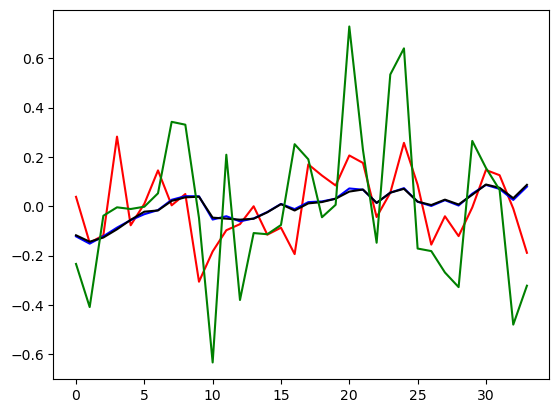

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
# # plot the weights
plt.close('all')
################# plot the rmse #################
fig, ax = plt.subplots()

# plot the ground truth in a specific location
idx_run = 0
idx_grid_cell = 100

time_period =34


# plot the ground truth
plt.plot(range(time_period),y[m0][idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='GT',color='red')
plt.plot(range(time_period),y_pred_ridge[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='ridge',color='blue')
plt.plot(range(time_period),y_pred_ridge_lr[idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='ridge low rank',color='black')
plt.plot(range(time_period),x[m0][idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='input',color='green')
plt.show()

## PCA of matrix W to observe the low-rank subspace

In [ ]:
# compute PCA low rank decomposition of w_robust_lr with pytorch
U, S, V = torch.pca_lowrank(w_robust_trace, q=7)

# compute projection of w_robust_lr onto low rank coordinate 
w_proj = w_robust_trace @ V
w_proj[nan_idx,:] = float('nan')

V[nan_idx,:] = float('nan') # set nan values to nan

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

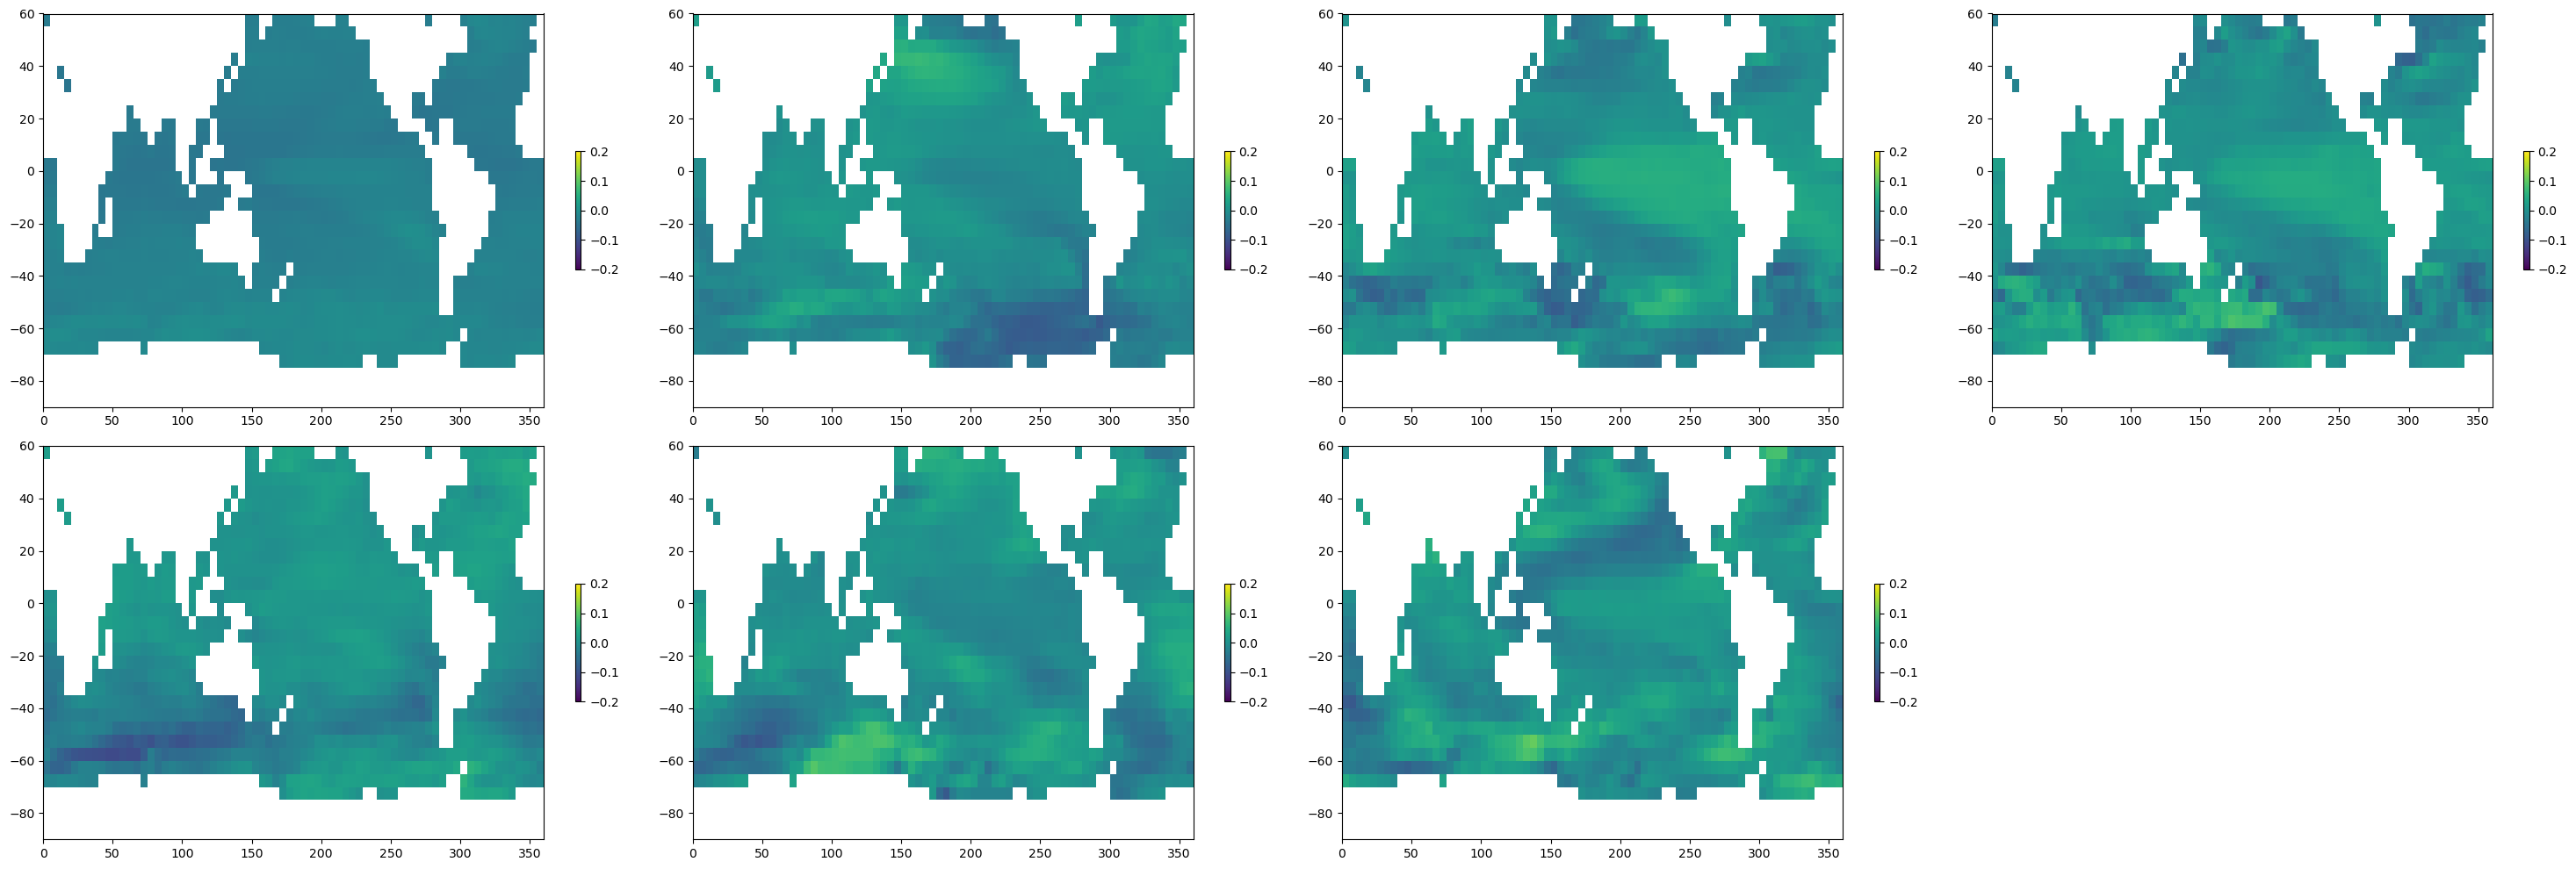

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
# # display 9 first projected components as grid maps 

plt.close('all')
fig, ax = plt.subplots(2, 4, figsize=(30, 10))
vmin = -0.2
vmax = 0.2
for i in range(7):
    ax_i = ax[i//4, i%4]
    im = ax_i.pcolormesh(lon_grid, lat_grid, V[:, i].detach().numpy().reshape(lat_size, lon_size), vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax_i, shrink=0.3)
ax[1,3].remove()
plt.tight_layout()
plt.show()


# Compute linear trend per grid cell

In [ ]:
# # Sample time series data (y values)
# y_tmp = y_train.T
# print(y_tmp.shape)

# # Time indices
# t = torch.arange(len(y), dtype=torch.float32).unsqueeze(1)  # Reshape for linear regression

# # Add bias term (column of ones for intercept)
# X = torch.cat([t, torch.ones_like(t)], dim=1)  # Shape: (n,2), where first column is t, second is bias

# # Solve for linear regression coefficients: (X^T X)^(-1) X^T y
# theta = torch.linalg.lstsq(X, y).solution  # Least squares solution

# # Extract slope and intercept
# slope, intercept = theta[0].item(), theta[1].item()

# # Compute fitted trend
# trend = X @ theta

# # Print results
# print(f"Slope (b): {slope}")
# print(f"Intercept (a): {intercept}")
# print(f"Fitted Trend: {trend.numpy()}")

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 